# Archetypal Analysis (AA) on Mouse embryonic brain dataset
This notebook applies AA on the mouse embryonic brain scRNA+ATAC dataset. Prior to this analysis, data should be processed correctly and contained within processed_data/ folder. See processed_data/Readme.txt and ArchVelo_data_preparation.ipynb for details.

In [4]:
import numpy as np
import pandas as pd

In [5]:
import matplotlib.pyplot as plt

In [6]:
import os

In [12]:
import sys
sys.path.append('../') 
from archetypal_regression.archetypes import *

In [14]:
data_outdir = 'processed_data/'
model_outdir = 'modeling_results/'
outdir = model_outdir+'archetypes/'
os.makedirs(outdir, exist_ok = True)
fig_outdir = 'figures/'
os.makedirs(fig_outdir, exist_ok = True)

In [25]:
num_comps = 10

# Read in data

In [17]:
# preprocessed ATAC for ArchVelo
atac = sc.read_h5ad(data_outdir+'adata_atac_raw.h5ad')

In [18]:
# preprocessed ATAC for ArchVelo
adata_rna = sc.read_h5ad(data_outdir+'adata_rna.h5ad')

In [20]:
np.random.seed(42)

In [34]:
XC, S = apply_AA_no_test(atac, 
                  k = num_comps,
                  outdir = outdir, 
                  )

Applying AA...

Principal Convex Hull Analysis / Archetypal Analysis
A 7 component model will be fitted
To stop algorithm press control C

-----------+------------+------------+-------------+------------+------------+------------+------------+
 Iteration | Expl. var. | Cost func. | Delta SSEf. |        muC |    mualpha |        muS |  Time(s)   
-----------+------------+------------+-------------+------------+------------+------------+------------+
         1 |     0.0068 | 5.1262e+07 | 1.5109e-01 | 1.9349e-01 | 6.1917e+00 | 4.6146e+00 |     5.0000 

         2 |     0.0131 | 5.0935e+07 | 6.4047e-03 | 1.1980e+00 | 3.8338e+01 | 1.4286e+01 |     4.0000 

         3 |     0.0145 | 5.0864e+07 | 1.4091e-03 | 2.3181e-01 | 2.3738e+02 | 5.5285e+00 |     5.0000 

         4 |     0.0147 | 5.0853e+07 | 2.1623e-04 | 1.4353e+00 | 1.4698e+03 | 4.2789e+00 |     4.0000 

         5 |     0.0149 | 5.0842e+07 | 2.1584e-04 | 8.8871e+00 | 9.1004e+03 | 3.3117e+00 |     4.0000 

         6 |     0.0151 | 5

In [23]:
outdir

'modeling_results/archetypes/'

In [28]:
XC = pd.read_csv(outdir+'cell_on_peaks_'+str(num_comps)+'_comps.csv', index_col = [0])
adata_rna.obs[['A_'+str(i) for i in range(num_comps)]] = XC.values

In [29]:
%matplotlib inline

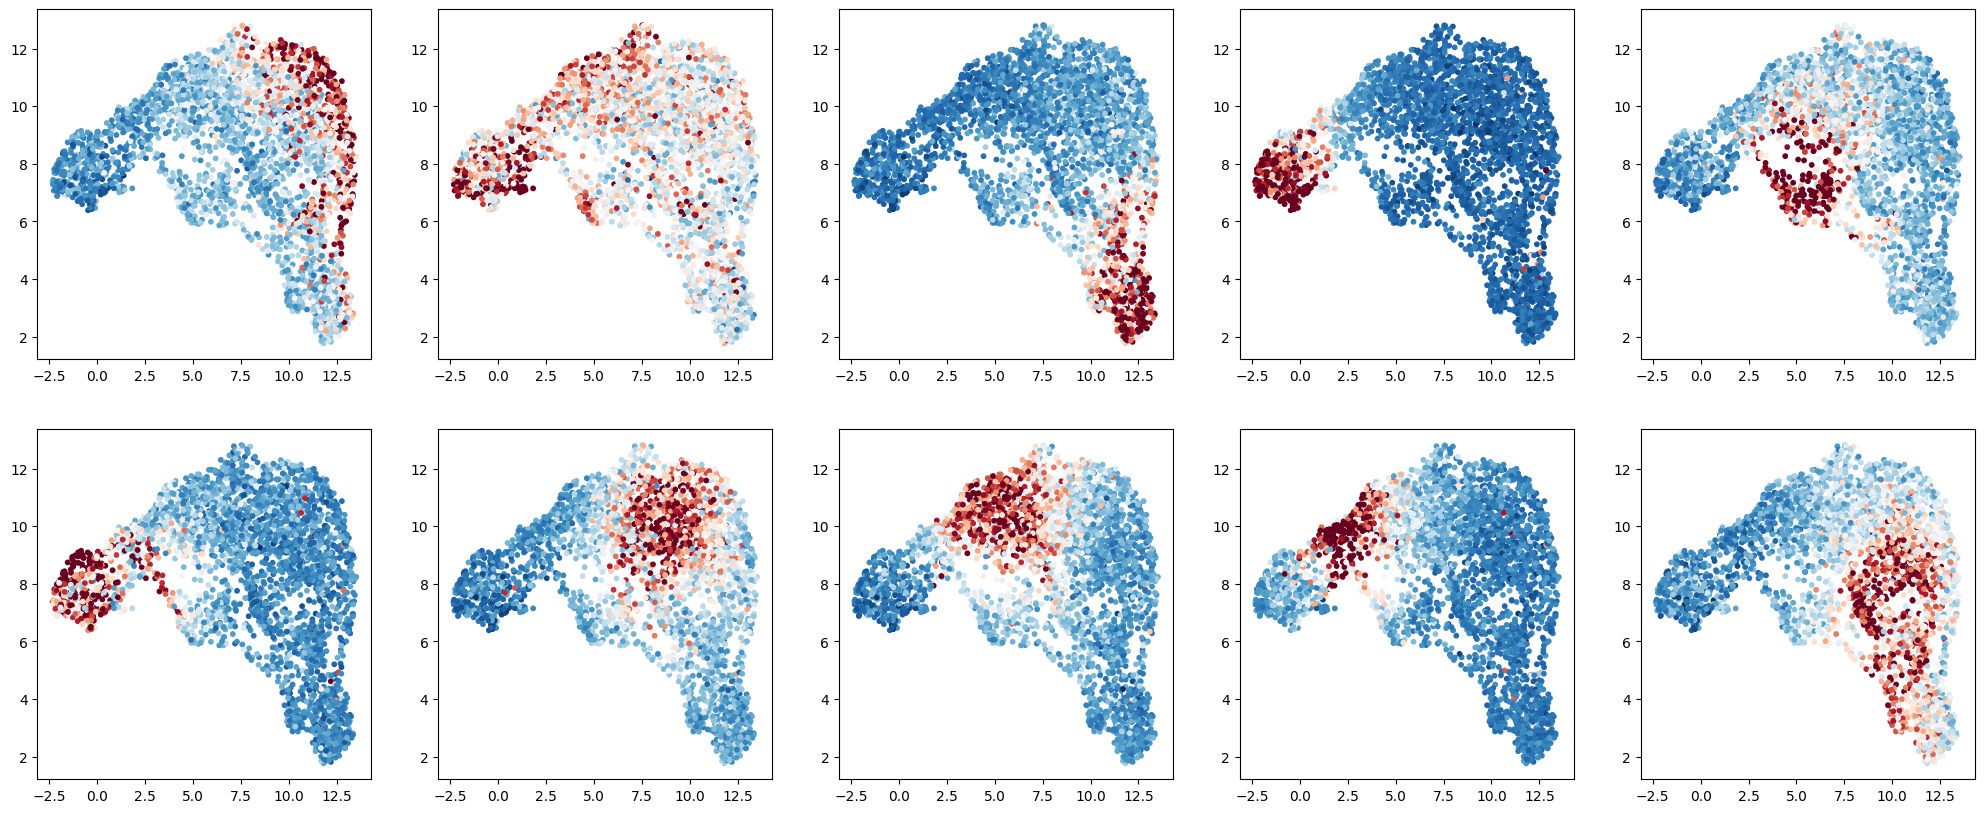

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (25,10))
for i in range(num_comps):
    comp = np.ravel(XC.iloc[:,i])
    plt.subplot(2,5,i+1)
    plt.scatter(adata_rna.obsm['X_umap'][:,0],
                adata_rna.obsm['X_umap'][:,1],
                c = comp,
               vmax = np.percentile(comp, 96),
               s = 10,
               cmap = 'RdBu_r')

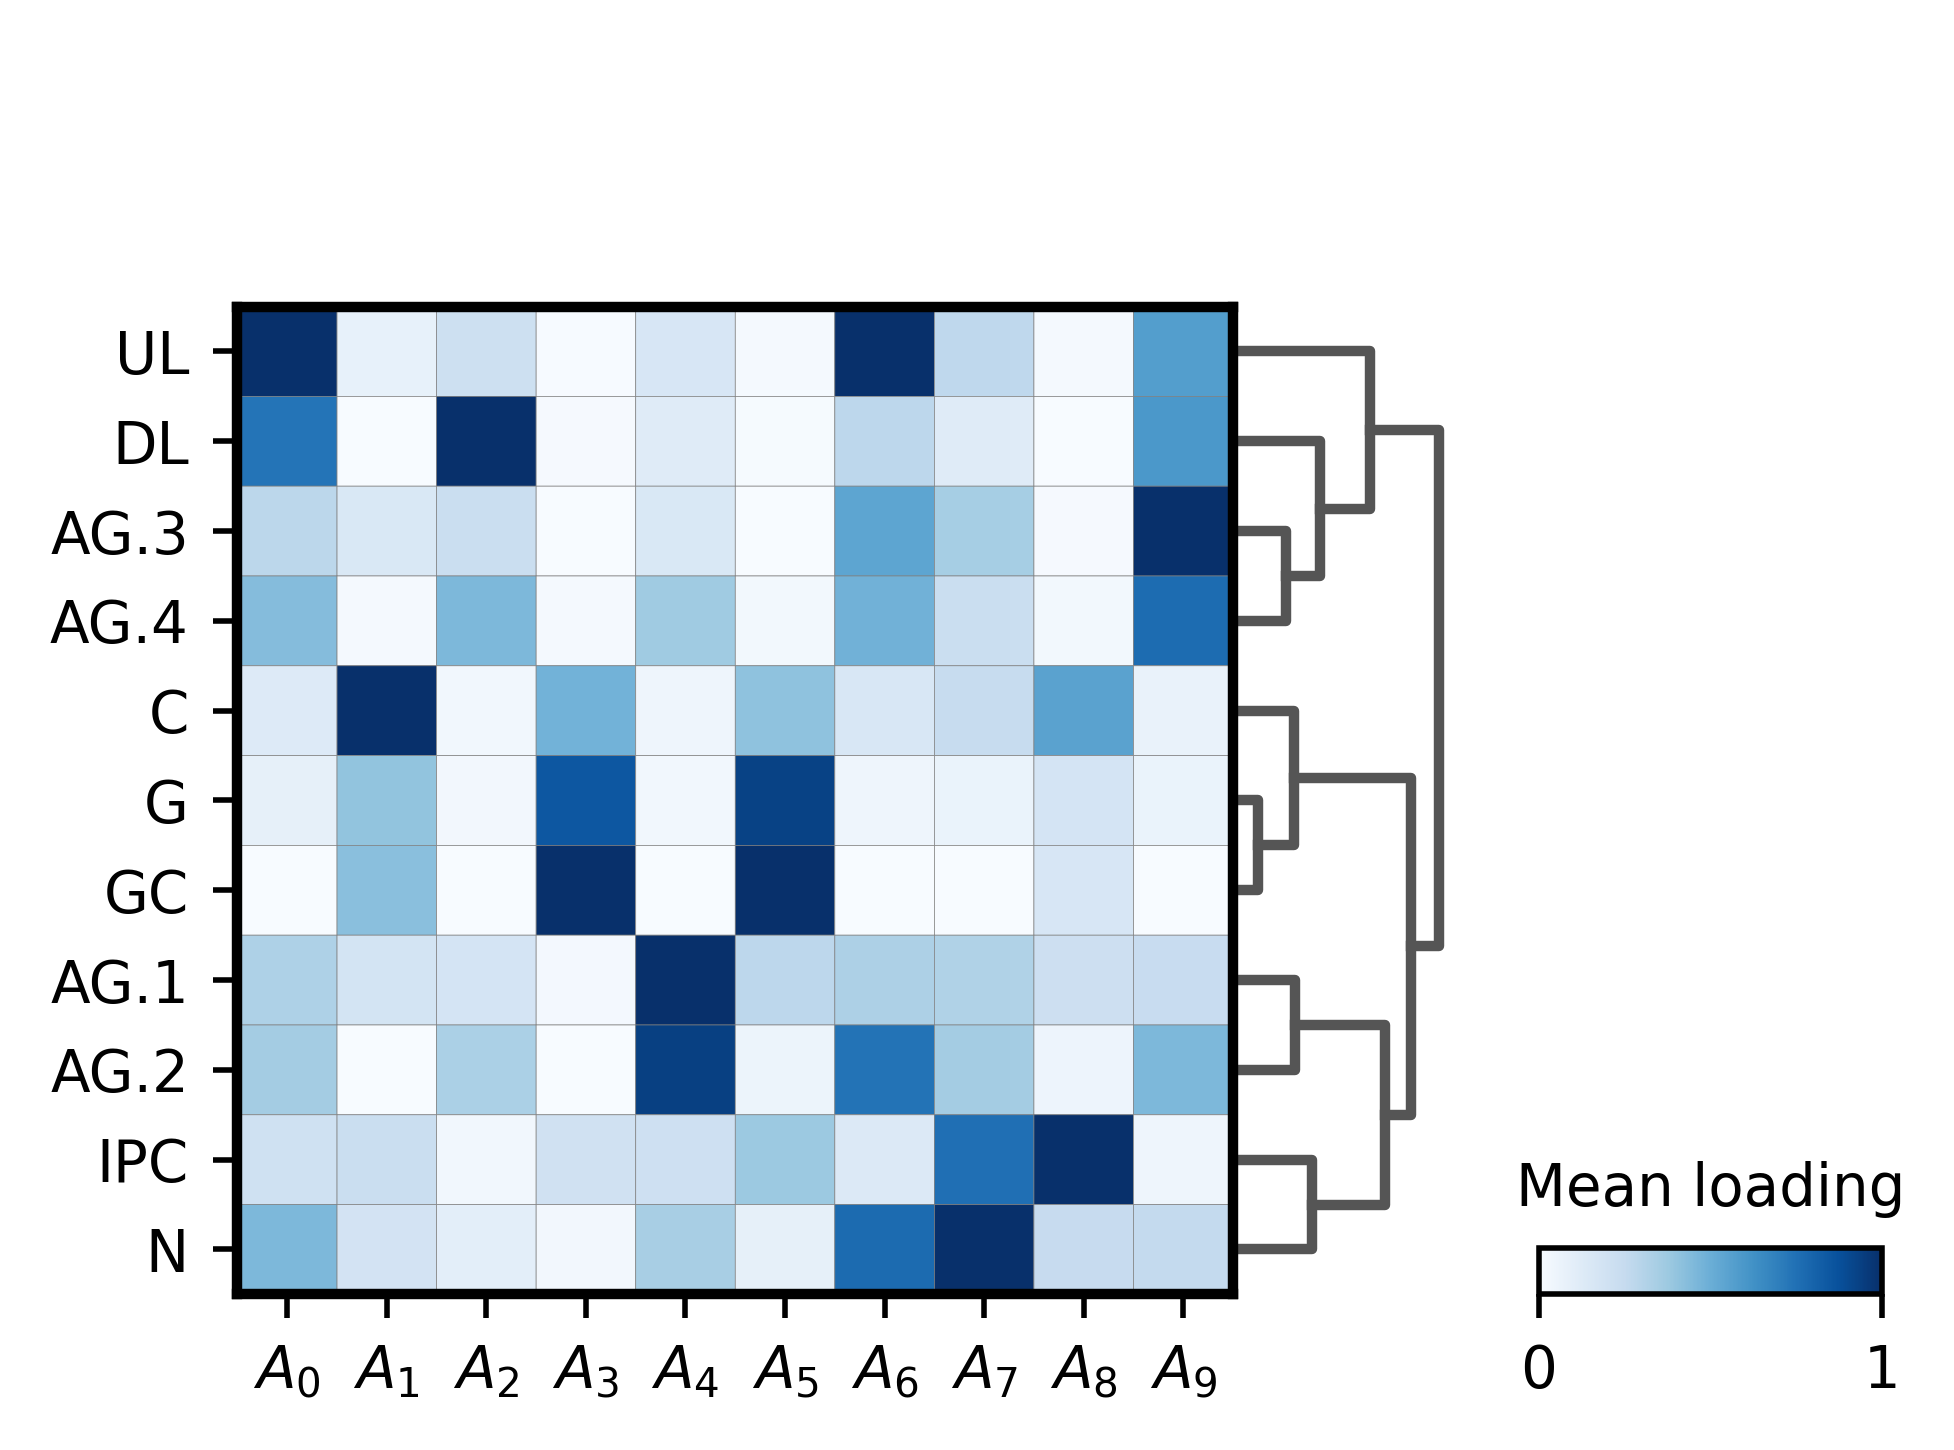

In [35]:
# 10 comps
fig, ax = plt.subplots(1,1,dpi = 500, figsize = (4,3))
g = sc.pl.matrixplot(adata_rna, ['A_'+str(i) for i in range(num_comps)],
                     groupby = 'cell_type_abbr', 
                     standard_scale = 'var', 
                     #return_fig=True,
                     show = False,
                     dendrogram = True, cmap = 'Blues', swap_axes = False,
                     ax = ax,
                     colorbar_title = 'Mean loading')
g['mainplot_ax'].set_xticks(np.arange(0,num_comps)+0.5, 
                            ['$A_'+str(i)+'$' for i in range(num_comps)],
                           rotation = 0)
#g['color_legend_ax'].set_position([0,1.5,0.1,0.1])
plt.tight_layout()
fig.savefig(fig_outdir+'Archetypes_per_celltype_rotated.png', dpi = 600)
fig.savefig(fig_outdir+'Archetypes_per_celltype_rotated.svg', dpi = 600)
#g.show()